# Práctica computacional 3: Ciclos circadianos y comportamiento animal


<a href="https://colab.research.google.com/github/Nieto-CaballeroVE/CdeCMx2025_GTO4/blob/master/notebooks/ComputerLab3_Behavior.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

El comportamiento animal muestra patrones en diversas escalas temporales, que van desde secuencias repetidas de movimientos que ocurren durante minutos, pasando por los ritmos circadianos en un período de 24 horas, hasta los cambios conductuales que se producen a lo largo de la vida. <br> <br>
Avances recientes en visión por computadora y aprendizaje automático ahora nos permiten medir estos comportamientos de forma cuantitativa, brindándonos una comprensión más profunda de qué conductas están presentes y de las complejas secuencias temporales que conforman. <br> <br>
En esta práctica investigaremos patrones de comportamiento de *Drosophila* durante distintos momentos del ciclo circadiano.

## Conociendo los datos

Usaremos un dataset público disponible en: https://datacommons.princeton.edu/discovery/catalog/doi-10-34770-1sab-8845. <br>

En dicho trabajo, se grabaron moscas *D. melanogaster* comportándose libremente en arenas individuales de manera continua durante 4-8 días, a 100 Hz y con una resolución de 28.25 píxeles/mm en un ciclo de 12 horas de luz/12 de oscuridad.


![](https://github.com/Nieto-CaballeroVE/CdeCMx2025_GTO4/blob/main/media/journal.pcbi.1012753.g001.PNG?raw=true)

 Si quieres saber más, puedes consultar la publicación en:

https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1012753



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from IPython.display import Video

# Ejemplo de grabaciones durante el dia y la noche
fly_awake = '/content/drive/MyDrive/CdeCMx2025_GTO4/videos_muestra/fly_awake.mp4'
fly_sleep = '/content/drive/MyDrive/CdeCMx2025_GTO4/videos_muestra/fly_sleep.mp4'

# Mosca "despierta"
Video(fly_awake, embed=True, width=640, height=480)


Output hidden; open in https://colab.research.google.com to view.

In [3]:
# Mosca "dormida"
Video(fly_sleep, embed=True, width=640, height=480)

Output hidden; open in https://colab.research.google.com to view.

## 0. Behavioral tracking
Después de las grabaciones experimentales, el primer paso consiste obtener datos numericos a partir del video.
Esto se conoce “seguimiento del comportamiento” o **"behavioral tracking"**.<br><br>
Hemos realizado previamente este preprocesamiento de los videos con un software llamado `Trex`, el cual usa computer vision e inteligencia artificial. Si quieres conocer mas detalles puedes consultar: https://trex.run/

In [4]:
# Especificar nuestro directorio de trabajo
%cd /content/drive/My\ Drive/behavior_fly
!ls

/content/drive/My Drive/behavior_fly
20220418_cam4_flid46_off_0_fish0.npz
20220418_cam4_flid46_off_0_statistics.npz
20220418_cam4_flid46_off_1_fish0.npz
20220418_cam4_flid46_off_1_statistics.npz
20220418_cam4_flid46_on_0_fish0.npz
20220418_cam4_flid46_on_0_statistics.npz
20220418_cam4_flid46_on_1_fish0.npz
20220418_cam4_flid46_on_1_statistics.npz
20220418_cam4_flid46_transitionoff_0_fish0.npz
20220418_cam4_flid46_transitionoff_0_statistics.npz
20220418_cam4_flid46_transitionon_0_fish0.npz
20220418_cam4_flid46_transitionon_0_statistics.npz
20220418_cam4_flid46_trim-2_fish0.npz


In [5]:
# Instalar librerías con funciones útiles para nuestro análisis y visualización.
!pip install statannot
!pip install npstructures

In [7]:
# Cargar librerías
import os
import pathlib
from pprint import pprint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.pyplot import figure
mpl.rcParams['figure.dpi']= 500
import math
import statistics as statis
import seaborn as sns
import sys
import plotly.express as px
from statannot import add_stat_annotation
from scipy import stats
from scipy import signal
import math
from npstructures import RaggedArray
from tqdm import tqdm
from numba import jit
from matplotlib.gridspec import GridSpec
import plotly.io as pio

## 1. Definir funciones para el analisis de comportamiento animal

Definiremos una clase llamada `animal_behavior_stats` que sirve para cargar y organizar datos de comportamiento animal registrados en archivos `.npz` (por ejemplo, trayectorias de peces).<br> <br>
En pocas palabras, la clase hace lo siguiente:


1.   **Lee los archivos** <br>
Acepta un único archivo .npz o recorre un árbol de carpetas para encontrar todos los archivos .npz.
Cada archivo contiene la posición (X, Y), velocidad, ángulo, aceleración y una máscara de cuadros faltantes para un individuo.

2.   **Limpia y normaliza los datos** <br>
Elimina valores infinitos o negativos.
Escala las coordenadas X a un rango de –1 a 1 y las Y a 0 – 1.

3.   **Guarda la información** <br>
Almacena las series de posición, velocidad, ángulo y aceleración de cada individuo en listas que luego convertimos en un `RaggedArray` (útil para series de diferente longitud).
Cuenta los “animales raros” (trayectorias demasiado cortas).

4.   **Genera trayectorias suavizadas** <br>
Para trayectorias con al menos 10 puntos, interpola con splines cúbicos las señales de posición X y velocidad en una línea temporal fija (definida por el trial_length, p. ej. 600 s).
Al final guardamos estas curvas suavizadas en dataframes (spline_x, spline_sp) para análisis posteriores.


In [8]:
class animal_behavior_stats:
    def __init__(self, path, trial_length=600, label="experiment"):
        self.path          = path
        self.label         = label
        self.trial_length  = trial_length
        self.time          = np.linspace(0, trial_length, trial_length)

        # containers
        self.x, self.y     = [], []
        self.sp, self.an   = [], []
        self.ac            = []
        self.spline_x      = pd.DataFrame()
        self.spline_sp     = pd.DataFrame()
        self.weird_animal    = 0

        self._load_data()
        self.num_indiv = len(self.x)
        print(f"Loaded {self.num_indiv} animal")

    # ------------------------------------------------------------------ #
    def _load_data(self):
        """Populate self.* with data from one file or a directory tree."""
        # ---------- Accept both a single file and a directory --------- #
        if os.path.isfile(self.path) and self.path.endswith(".npz"):
            list_files = [self.path]
        else:  # assume directory tree
            list_files = [
                os.path.join(root, f)
                for root, _, files in os.walk(self.path)
                for f in files
                if f.endswith(".npz")
            ]

        if not list_files:
            raise FileNotFoundError("No .npz files found at the supplied path.")

        # ----------- ingest each fish --------------------------------- #
        for file_path in tqdm(list_files, desc="Loading fish"):
            data  = np.load(file_path)
            mask  = ~data["missing"].astype(bool)

            x_pos = data["X#wcentroid"][mask]
            y_pos = data["Y#wcentroid"][mask]
            speed = data["SPEED"][mask]
            angle = data["ANGLE"][mask]
            acc   = data["ACCELERATION#wcentroid"][mask]

            # clean
            speed[(speed == np.inf) | (speed <= 0)] = 0
            angle[angle == np.inf] = 0
            acc[acc == np.inf]     = 0

            # -------- normalise coords (no left/right flip) ------------ #
            x_norm = (x_pos - np.nanmin(x_pos))
            x_norm = x_norm / ((np.nanmax(x_pos) - np.nanmin(x_pos)) / 2) - 1
            y_norm = (y_pos - np.nanmin(y_pos)) / (np.nanmax(y_pos) - np.nanmin(y_pos))

            # stash raw
            self.x .append(x_norm)
            self.y .append(y_norm)
            self.sp.append(speed)
            self.an.append(angle)
            self.ac.append(acc)

            # spline (skip very short tracks)
            if len(x_norm) < 10:
                self.weird_fish += 1
                continue
            self._add_splines(x_norm, speed)

        # convert to RaggedArray once
        self.x  = RaggedArray(self.x)
        self.y  = RaggedArray(self.y)
        self.sp = RaggedArray(self.sp)
        self.an = RaggedArray(self.an)
        self.ac = RaggedArray(self.ac)

    # ---------------- helpers ----------------------------------------- #
    def _add_splines(self, x_sig, sp_sig):
        from scipy.interpolate import CubicSpline
        ts   = np.linspace(0, self.trial_length, len(x_sig))
        cx   = CubicSpline(ts, x_sig)(self.time)
        cs   = CubicSpline(ts, sp_sig)(self.time)
        cs[cs < 0] = 0                           # speed only
        self.spline_x  = pd.concat([self.spline_x,  pd.Series(cx)],  axis=1)
        self.spline_sp = pd.concat([self.spline_sp, pd.Series(cs)],  axis=1)

Esencialmente tenemos datos en 3 dimensiones (coordenadas a través del tiempo). Podemos crear algunas funciones para empezar a explorar el comportamiento locomotor. <br><br>
No te preocupes si no entiendes cada línea de código; lo importante es saber, de forma general, qué hace cada una para interpretar los resultados.


1.   `plot_x_pos_single` – Dibuja la posición en el eje X normalizada de un solo animal a lo largo del tiempo (traza la línea horizontal de –1 a 1). Útil para ver cómo se mueve de izquierda a derecha durante la prueba.
2.   `plot_x_pos_single` – Dibuja la posición X normalizada de un solo animal a lo largo del tiempo (traza la línea horizontal de –1 a 1). Útil para ver cómo se mueve de izquierda a derecha durante la prueba.
3.  `plot_area_heatmap_single` – Genera un mapa de calor 2‑D que muestra en qué zonas del área pasa más tiempo el animal. Incluye histogramas marginales para X y Y.
4.  `plot_speed_single` – Traza la velocidad (suavizada con spline) del animal a lo largo del tiempo, con una referencia en 0 mm/s. Sirve para visualizar momentos de actividad e inactividad.
5.  `plot_trajectory_time_heatmap` – Muestra toda la trayectoria X–Y del animal; el color va de oscuro a claro según avanza el tiempo. Opción de marcar inicio/fin con puntos.
6.  `plot_cumulative_distance_spline` – Calcula y grafica la distancia acumulada recorrida (usando las trayectorias suavizadas) a lo largo de la sesión. Permite ver cuánto se desplazó en total.

In [9]:
def plot_x_pos_single(animal_obj,
                      title        = "Average X-position",
                      color        = "blue",
                      trial_length = None,
                      ylims        = (-1,1)):
    """
    Plot the normalised X-position of the single animal contained in `animal_obj`.

    Parameters
    ----------
    animal_obj : animal_behavior_stats
        Object returned by your loader (one fish inside).
    title : str
        Plot title.
    color : str
        Matplotlib colour spec.
    trial_length : int | None
        X-axis upper limit; defaults to animal_obj.trial_length.
    ylims : tuple(float, float)
        Y-axis limits.
    """

    # single column → numpy vector
    traj = animal_obj.spline_x.iloc[:, 0].values

    # --- plot --------------------------------------------------------- #
    plt.figure(figsize=(10, 7))
    plt.plot(animal_obj.time, traj, color=color, linewidth=4)

    ax = plt.gca()
    ax.set_ylim(*ylims)
    ax.set_xlim(0, trial_length)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.title(title, fontsize=20, fontweight='bold')
    plt.xlabel("Time (s)")
    plt.ylabel("X-Position (normalised)")
    plt.legend(["n = 1"], frameon=False)

    # reference line at centre
    plt.axhline(0, color='black', linestyle='--', linewidth=3)

    plt.show()

def plot_area_heatmap_single(
        animal_obj,
        title       = "Area heat-map",
        nbinsx      = 20,
        nbinsy      = 20,
        color_range = (0, 4)):
    """
    Show (and optionally save) a 2-D occupancy heat-map for a single animal.
    """

    # grab the first (and only) animal
    x_vals = pd.Series(animal_obj.x[0, :])
    y_vals = pd.Series(animal_obj.y[0, :])
    n_pts  = len(x_vals)

    df = pd.DataFrame({"X-position": x_vals, "Y-position": y_vals})

    fig = px.density_heatmap(
        df,
        x="X-position",
        y="Y-position",
        nbinsx=nbinsx,
        nbinsy=nbinsy,
        marginal_x="histogram",
        marginal_y="histogram",
        histnorm="percent",
        range_color=color_range,
    )

    # layout tweaks
    fig.update_layout(
        title=dict(text=f"<b>{title}</b>", x=0.5, y=0.95, xanchor="center"),
        font=dict(size=24),
        margin=dict(t=70, b=40, l=40, r=40),
    )
    fig.update_xaxes(title_font=dict(size=25))
    fig.update_yaxes(title_font=dict(size=25))

    # show it
    #fig.show()

    return fig

def plot_speed_single(
        animal_obj,
        title        = "Speed vs Time",
        color        = "blue",
        trial_length = None,
        ylims        = (0, 5),
        figsize      = (10, 5)):
    """
    Plot the spline-resampled speed (cm/s) for the single animal in `animal_obj`.

    Parameters
    ----------
    animal_obj      : animal_behavior_stats
    title         : str      – plot title
    color         : str      – line colour
    trial_length  : int|None – x-axis upper limit; defaults to animal_obj.trial_length
    ylims         : tuple    – (ymin, ymax)
    figsize       : tuple    – passed to plt.figure
    """

    # fall back to default trial length
    trial_length = trial_length or animal_obj.trial_length

    # safety: expect exactly one column
    if animal_obj.spline_sp.shape[1] == 0:
        raise ValueError("animal_obj.spline_sp is empty – did spline building run?")

    speed = animal_obj.spline_sp.iloc[:, 0].values   # one column → 1-D array

    plt.figure(figsize=figsize)
    plt.plot(animal_obj.time, speed, color=color, linewidth=3)

    ax = plt.gca()
    ax.set_ylim(*ylims)
    ax.set_xlim(0, trial_length)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.title(title, fontsize=20, fontweight="bold")
    plt.xlabel("Time (s)")
    plt.ylabel("Speed (mm/s)")
    plt.legend(["n = 1"], frameon=False)

    # reference line at 0 cm/s for context
    plt.axhline(0, linestyle="--", color="black", linewidth=1)

    plt.show()

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

def plot_trajectory_time_heatmap(animal_obj,
                                 cmap         = "viridis",
                                 figsize      = (5, 5),
                                 title        = "Trajectory (colour = time)",
                                 scatter_tail = False):
    """
    Draw the X–Y path; colour fades from start (dark) → end (bright).
    """

    x, y = animal_obj.x[0], animal_obj.y[0]
    t    = animal_obj.time[: len(x)]         # guard in case traces differ by 1 step

    # build line segments between successive points
    points   = np.vstack([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    norm = Normalize(vmin=t.min(), vmax=t.max())
    lc   = LineCollection(segments, cmap=cmap, norm=norm)
    lc.set_array(t[:-1])
    lc.set_linewidth(2)

    fig, ax = plt.subplots(figsize=figsize)
    ax.add_collection(lc)
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_aspect("equal")
    ax.set_xlabel("X (normalised)")
    ax.set_ylabel("Y (normalised)")
    ax.set_title(title, fontweight="bold")

    plt.colorbar(lc, ax=ax, label="Time (s)")

    # optional scatter on top to emphasise tail/head
    if scatter_tail:
        ax.scatter(x[0],  y[0],  c="black", s=40, label="start")
        ax.scatter(x[-1], y[-1], c="white", edgecolor="black", s=40, label="end")
        ax.legend()

    plt.show()

import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt

def plot_cumulative_distance_spline(
        animal_obj,
        title        = "Cumulative distance (spline)",
        color        = "tomato",
        y_label      = "Distance (arena units)",
        figsize      = (8,5)):

    x = animal_obj.spline_x.iloc[:, 0].values              # length = trial_length
    # if you stored spline_y, use it; else fall back to raw y resampled on-the-fly
    try:
        y = animal_obj.spline_y.iloc[:, 0].values
    except AttributeError:
        # quick 1-D spline of Y so we keep matching length
        from scipy.interpolate import CubicSpline
        raw_y = animal_obj.y[0]
        ts    = np.linspace(0, animal_obj.trial_length, len(raw_y))
        y     = CubicSpline(ts, raw_y)(animal_obj.time)

    step = np.sqrt(np.diff(x)**2 + np.diff(y)**2)
    cum  = np.concatenate([[0], np.cumsum(step)])

    plt.figure(figsize=figsize)
    plt.plot(animal_obj.time, cum, color=color, lw=3)
    plt.xlabel("Time (s)")
    plt.ylabel(y_label)
    plt.title(title, fontweight="bold")
    plt.tight_layout()
    plt.show()


 ## 2. Carga, limpieza y visualizacion de comportamiento locomotor

In [10]:
fly1 = animal_behavior_stats(path = r'20220418_cam4_flid46_trim-2_fish0.npz',label="test",trial_length =105)

Loading fish: 100%|██████████| 1/1 [00:00<00:00, 19.30it/s]

Loaded 1 animal


In [11]:
fly1.x

ragged_array([0.7278501  0.72719526 0.7274889  0.72729266 0.7273706  0.72769666
 0.7279984  0.7278217  0.7277466  0.72765625 0.7276299  0.72764325
 0.72773933 0.7273344  0.72699285 0.7275003  0.7279326  0.7282511
 0.7286606  0.72914636 0.7294371  0.72921395 0.72908294 0.728976
 0.72911584 0.72883725 0.72907746 0.729143   0.72893286 0.72895133
 0.72890246 0.72878706 0.7287388  0.7288333  0.72815263 0.72875714
 0.72844243 0.72821724 0.72833586 0.72783136 0.72783136 0.72855103
 0.7284546  0.72801447 0.7279897  0.7278652  0.7278497  0.7275896
 0.72735393 0.72709656 0.7270466  0.7268746  0.7266425  0.72671664
 0.7266662  0.7265861  0.726581   0.72660553 0.72656834 0.72659695
 0.7266315  0.72649205 0.72649026 0.7262511  0.7262956  0.72622347
 0.72627974 0.7262354  0.72625315 0.7263962  0.72647214 0.72671723
 0.7268665  0.727142   0.72733927 0.72709274 0.7271162  0.7270037
 0.7279211  0.7275275  0.72754    0.7276348  0.72774816 0.7284838
 0.72899926 0.72753453 0.7271234  0.72655284 0.7261386 

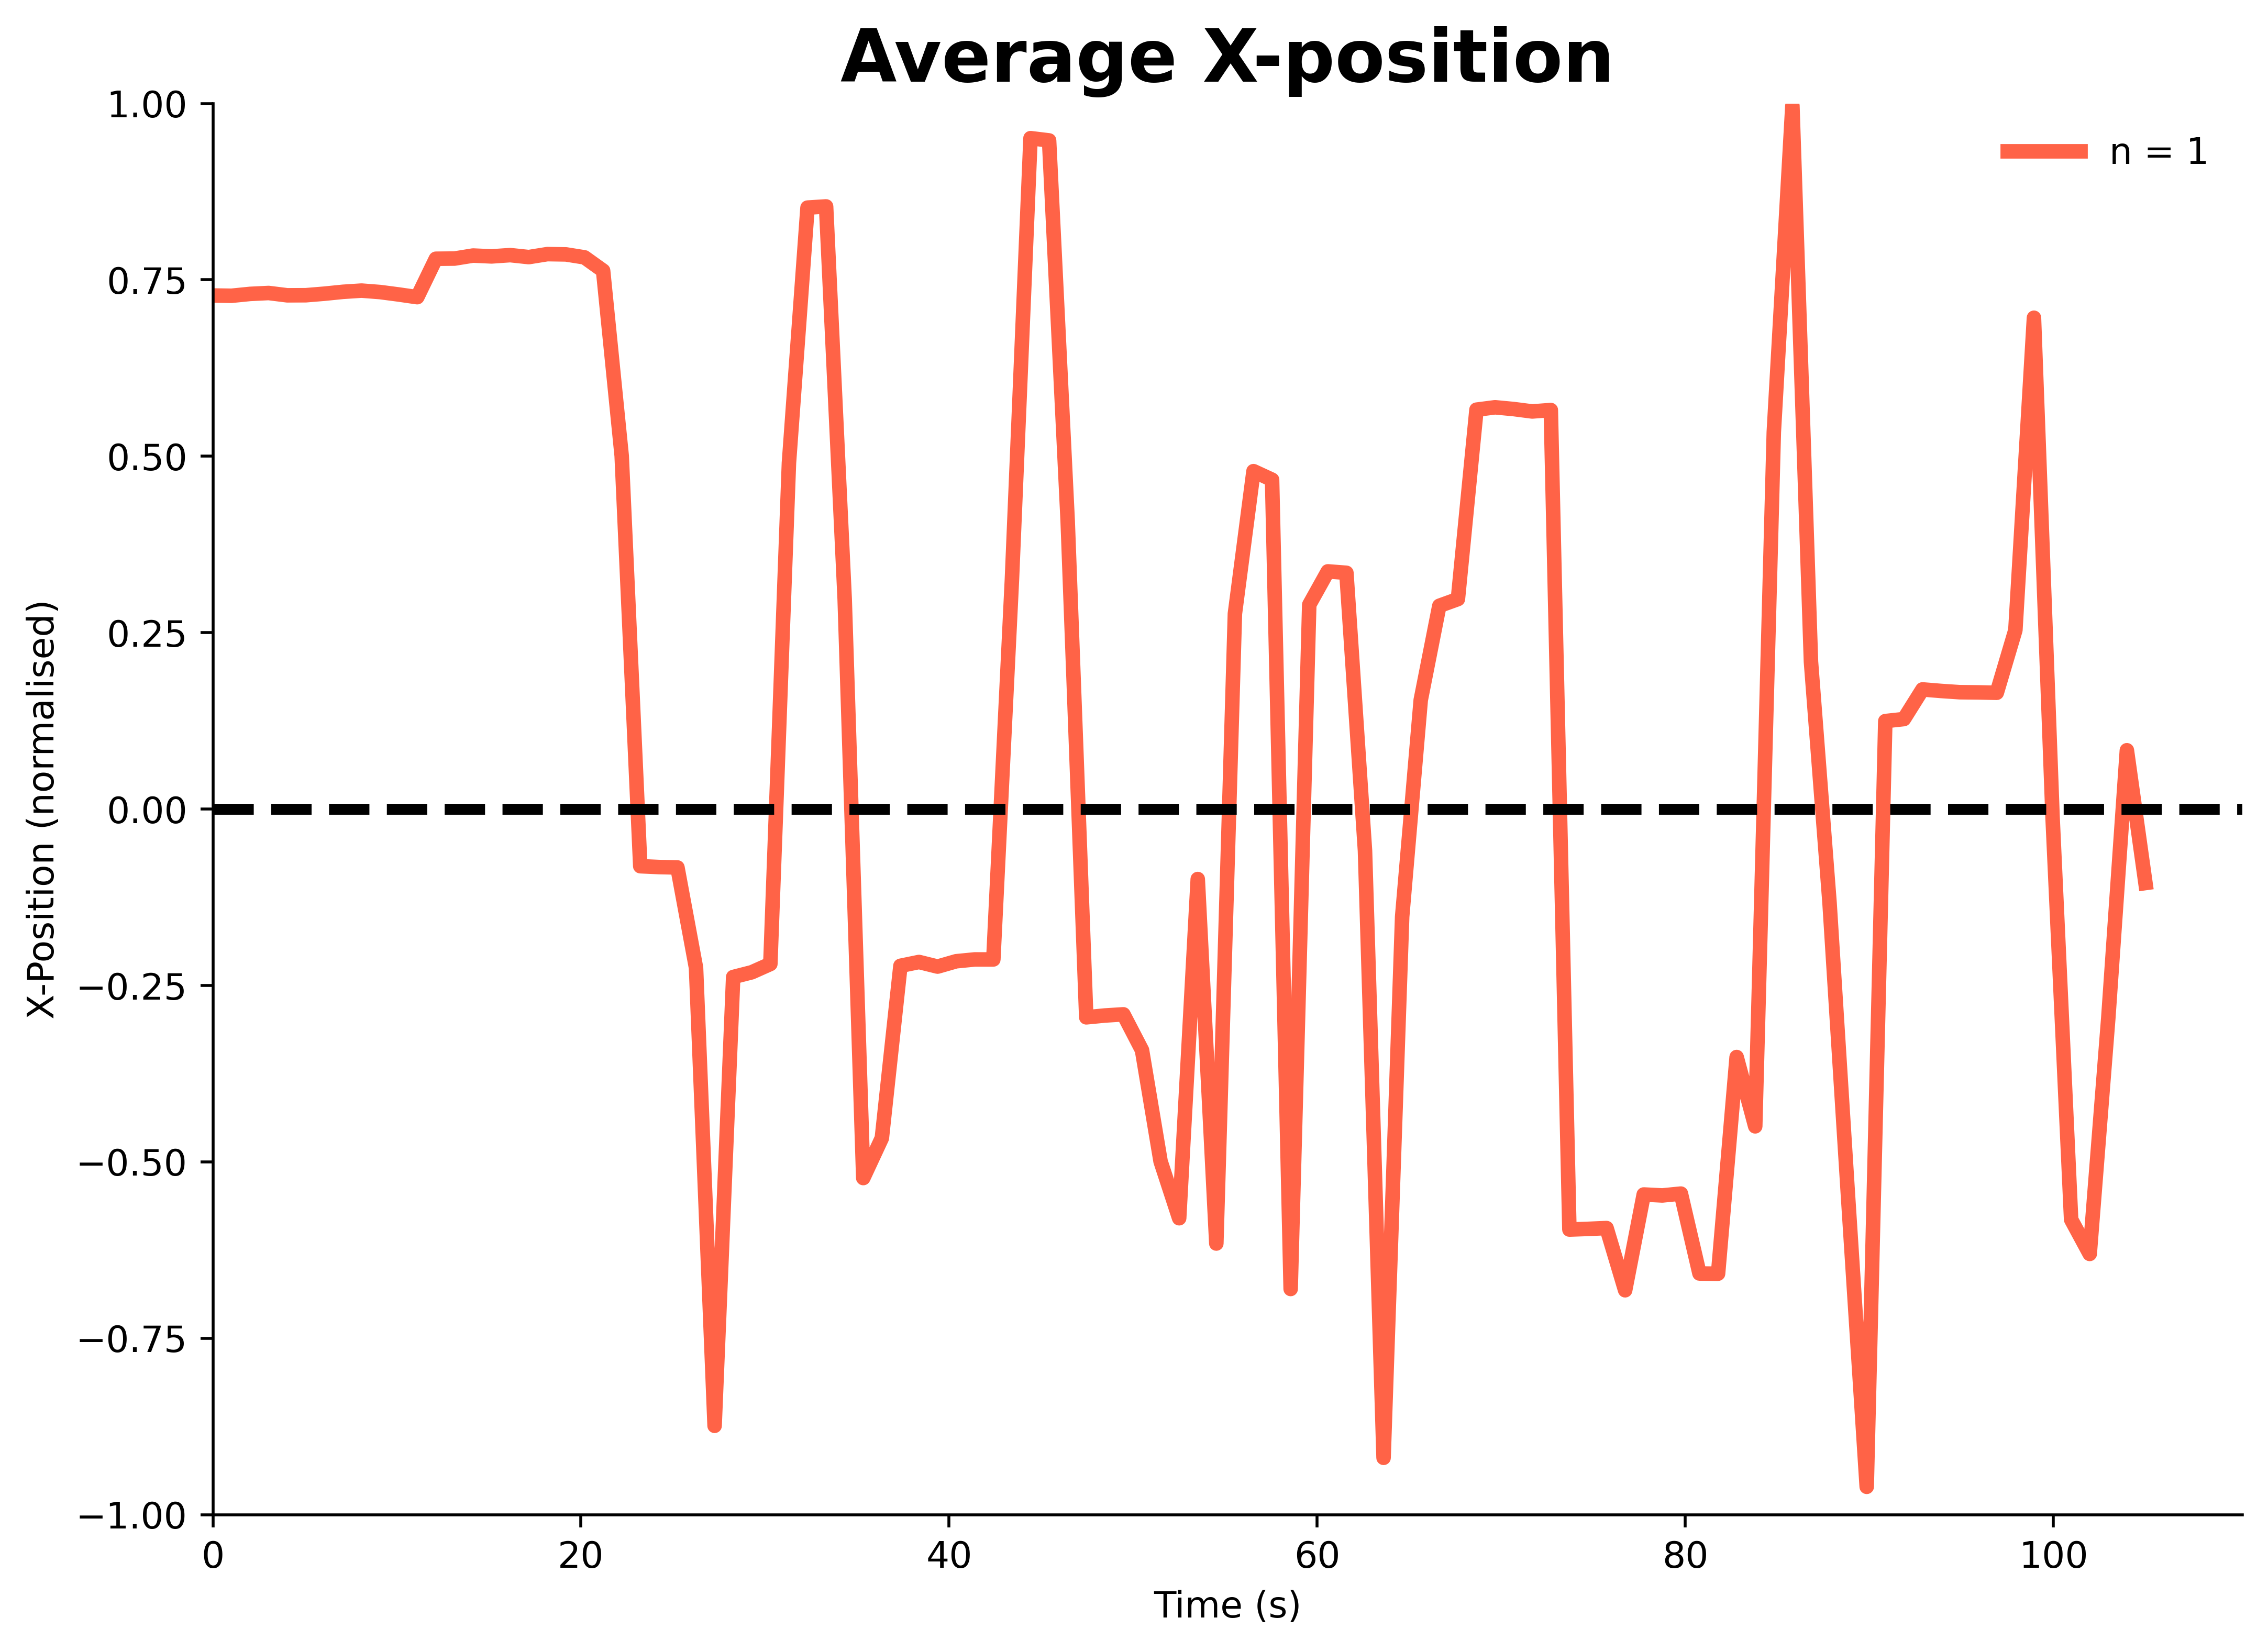

In [12]:
plot_x_pos_single(fly1, color="tomato")

In [13]:
plot_area_heatmap_single(fly1)

Output hidden; open in https://colab.research.google.com to view.

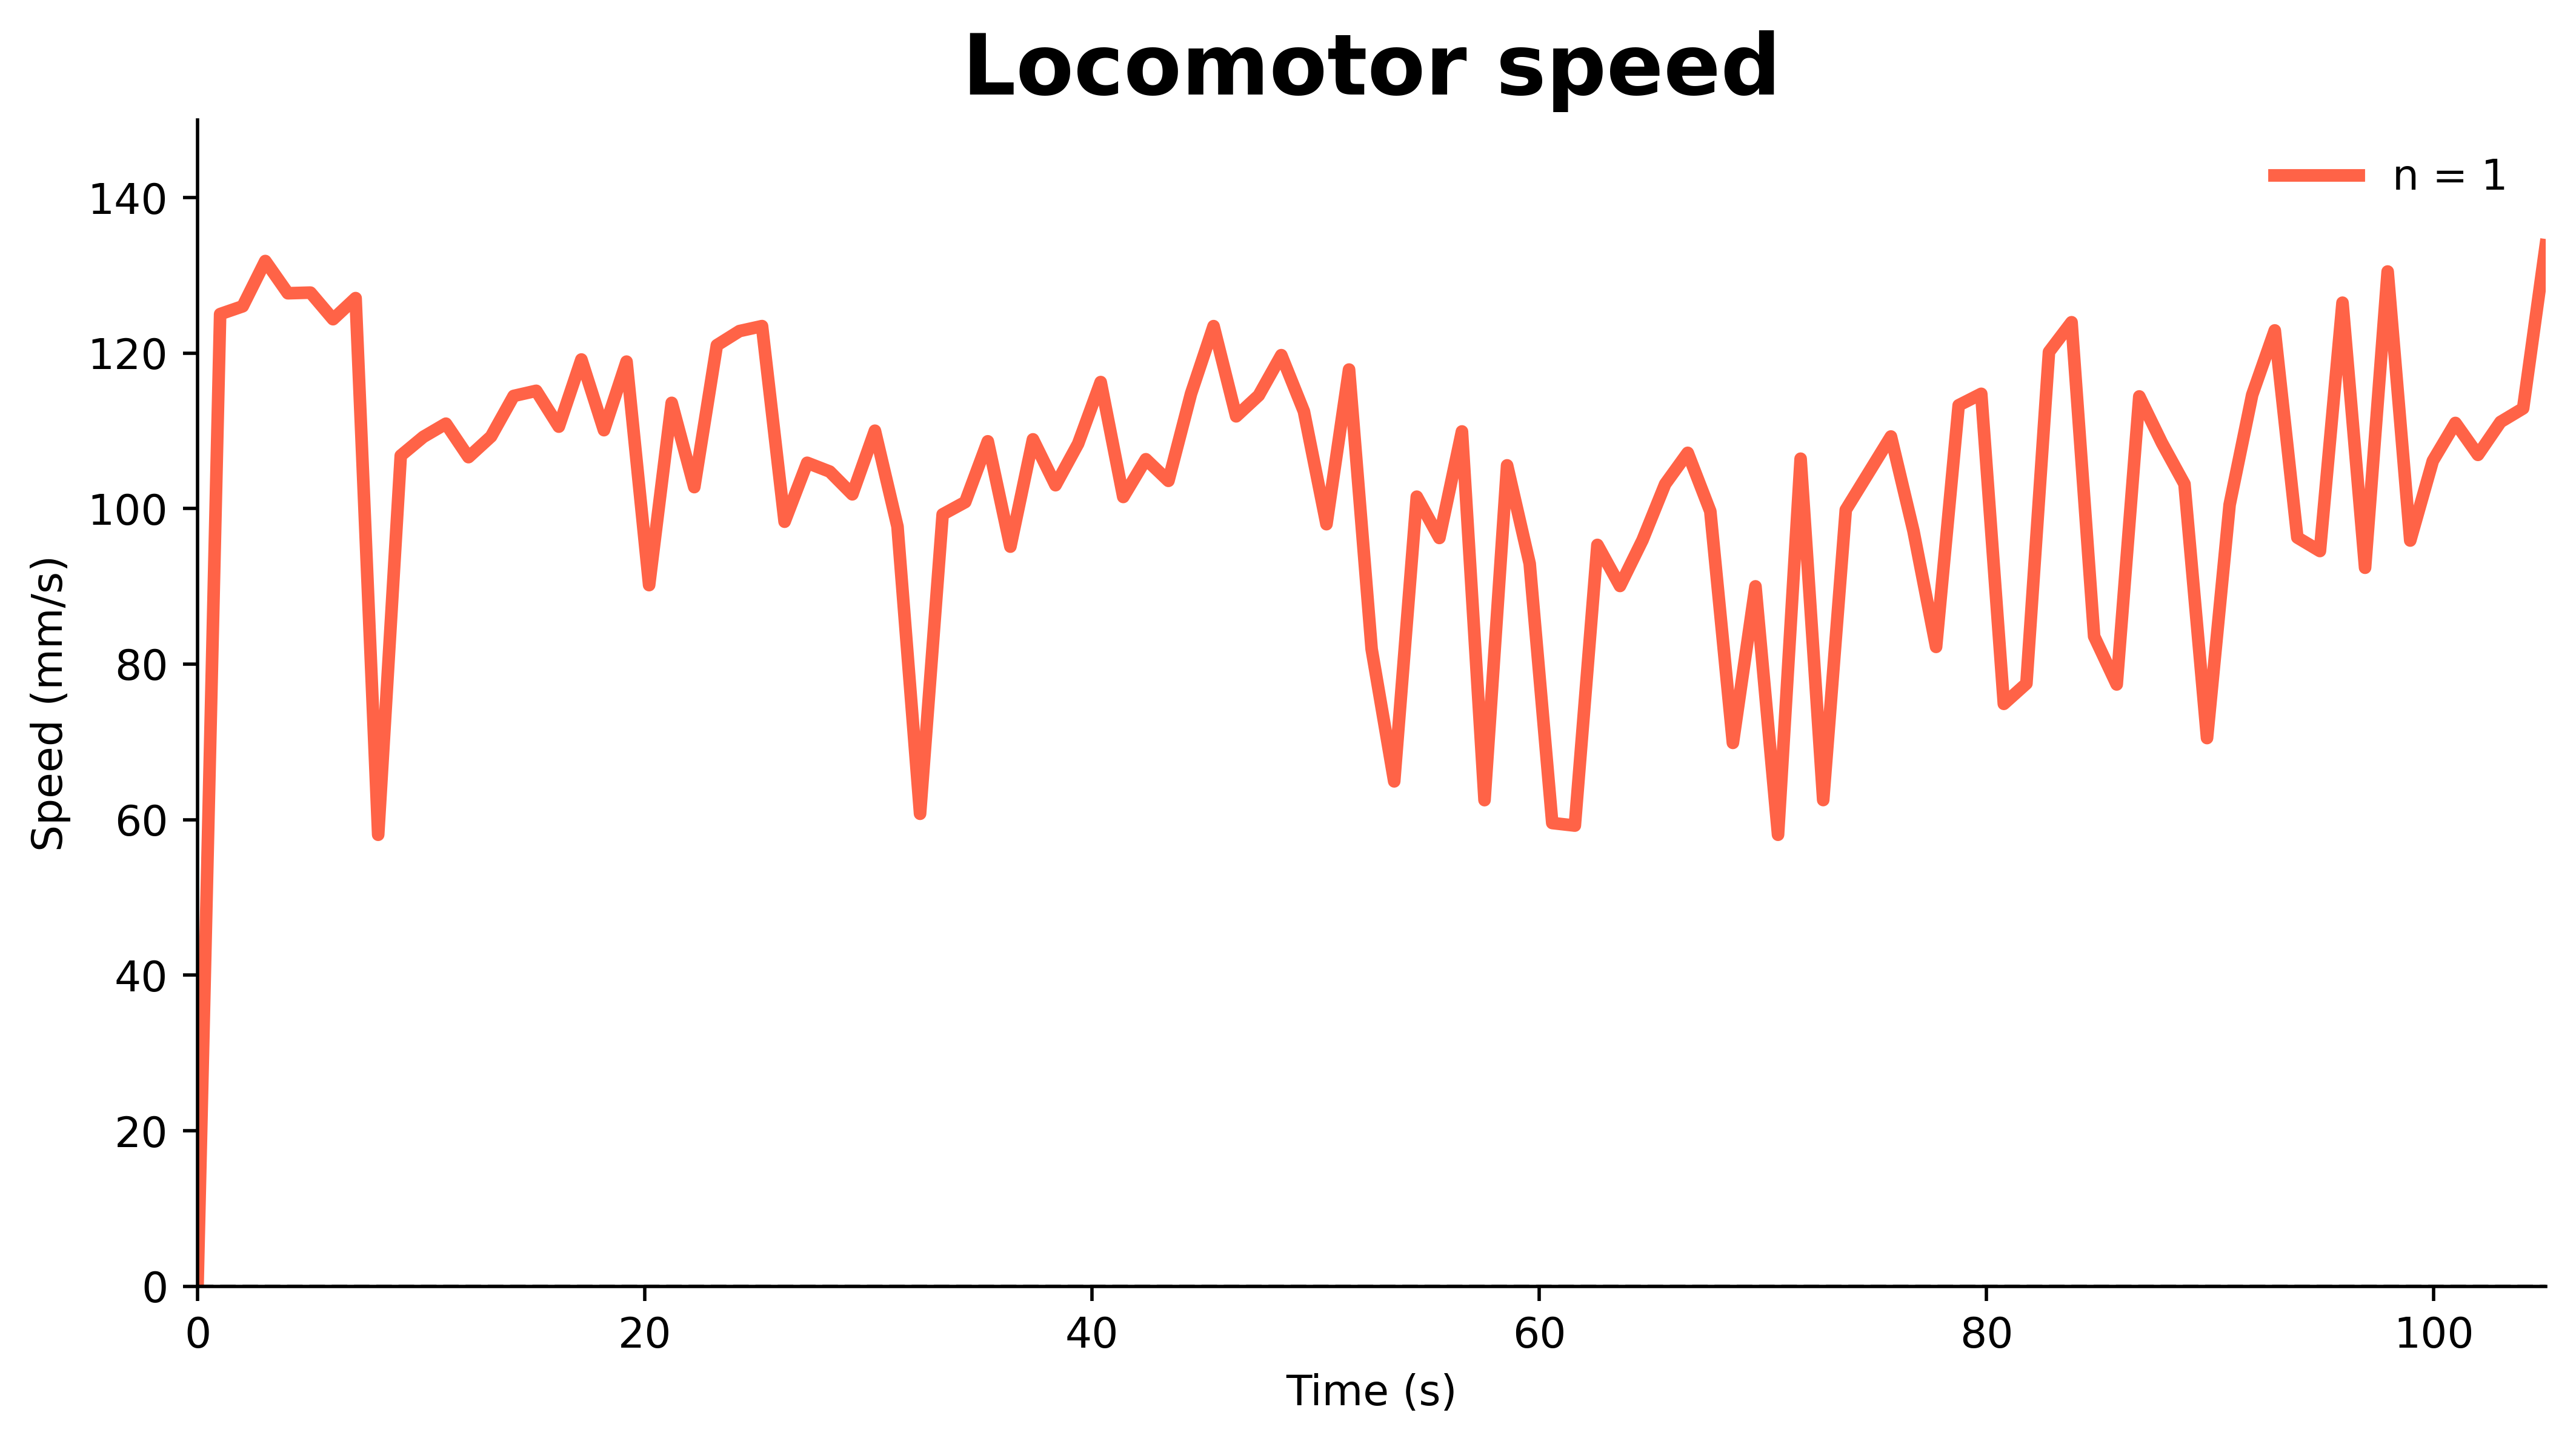

In [14]:
plot_speed_single(fly1,
                  title="Locomotor speed",
                  color="tomato",
                  ylims=(0, 150))

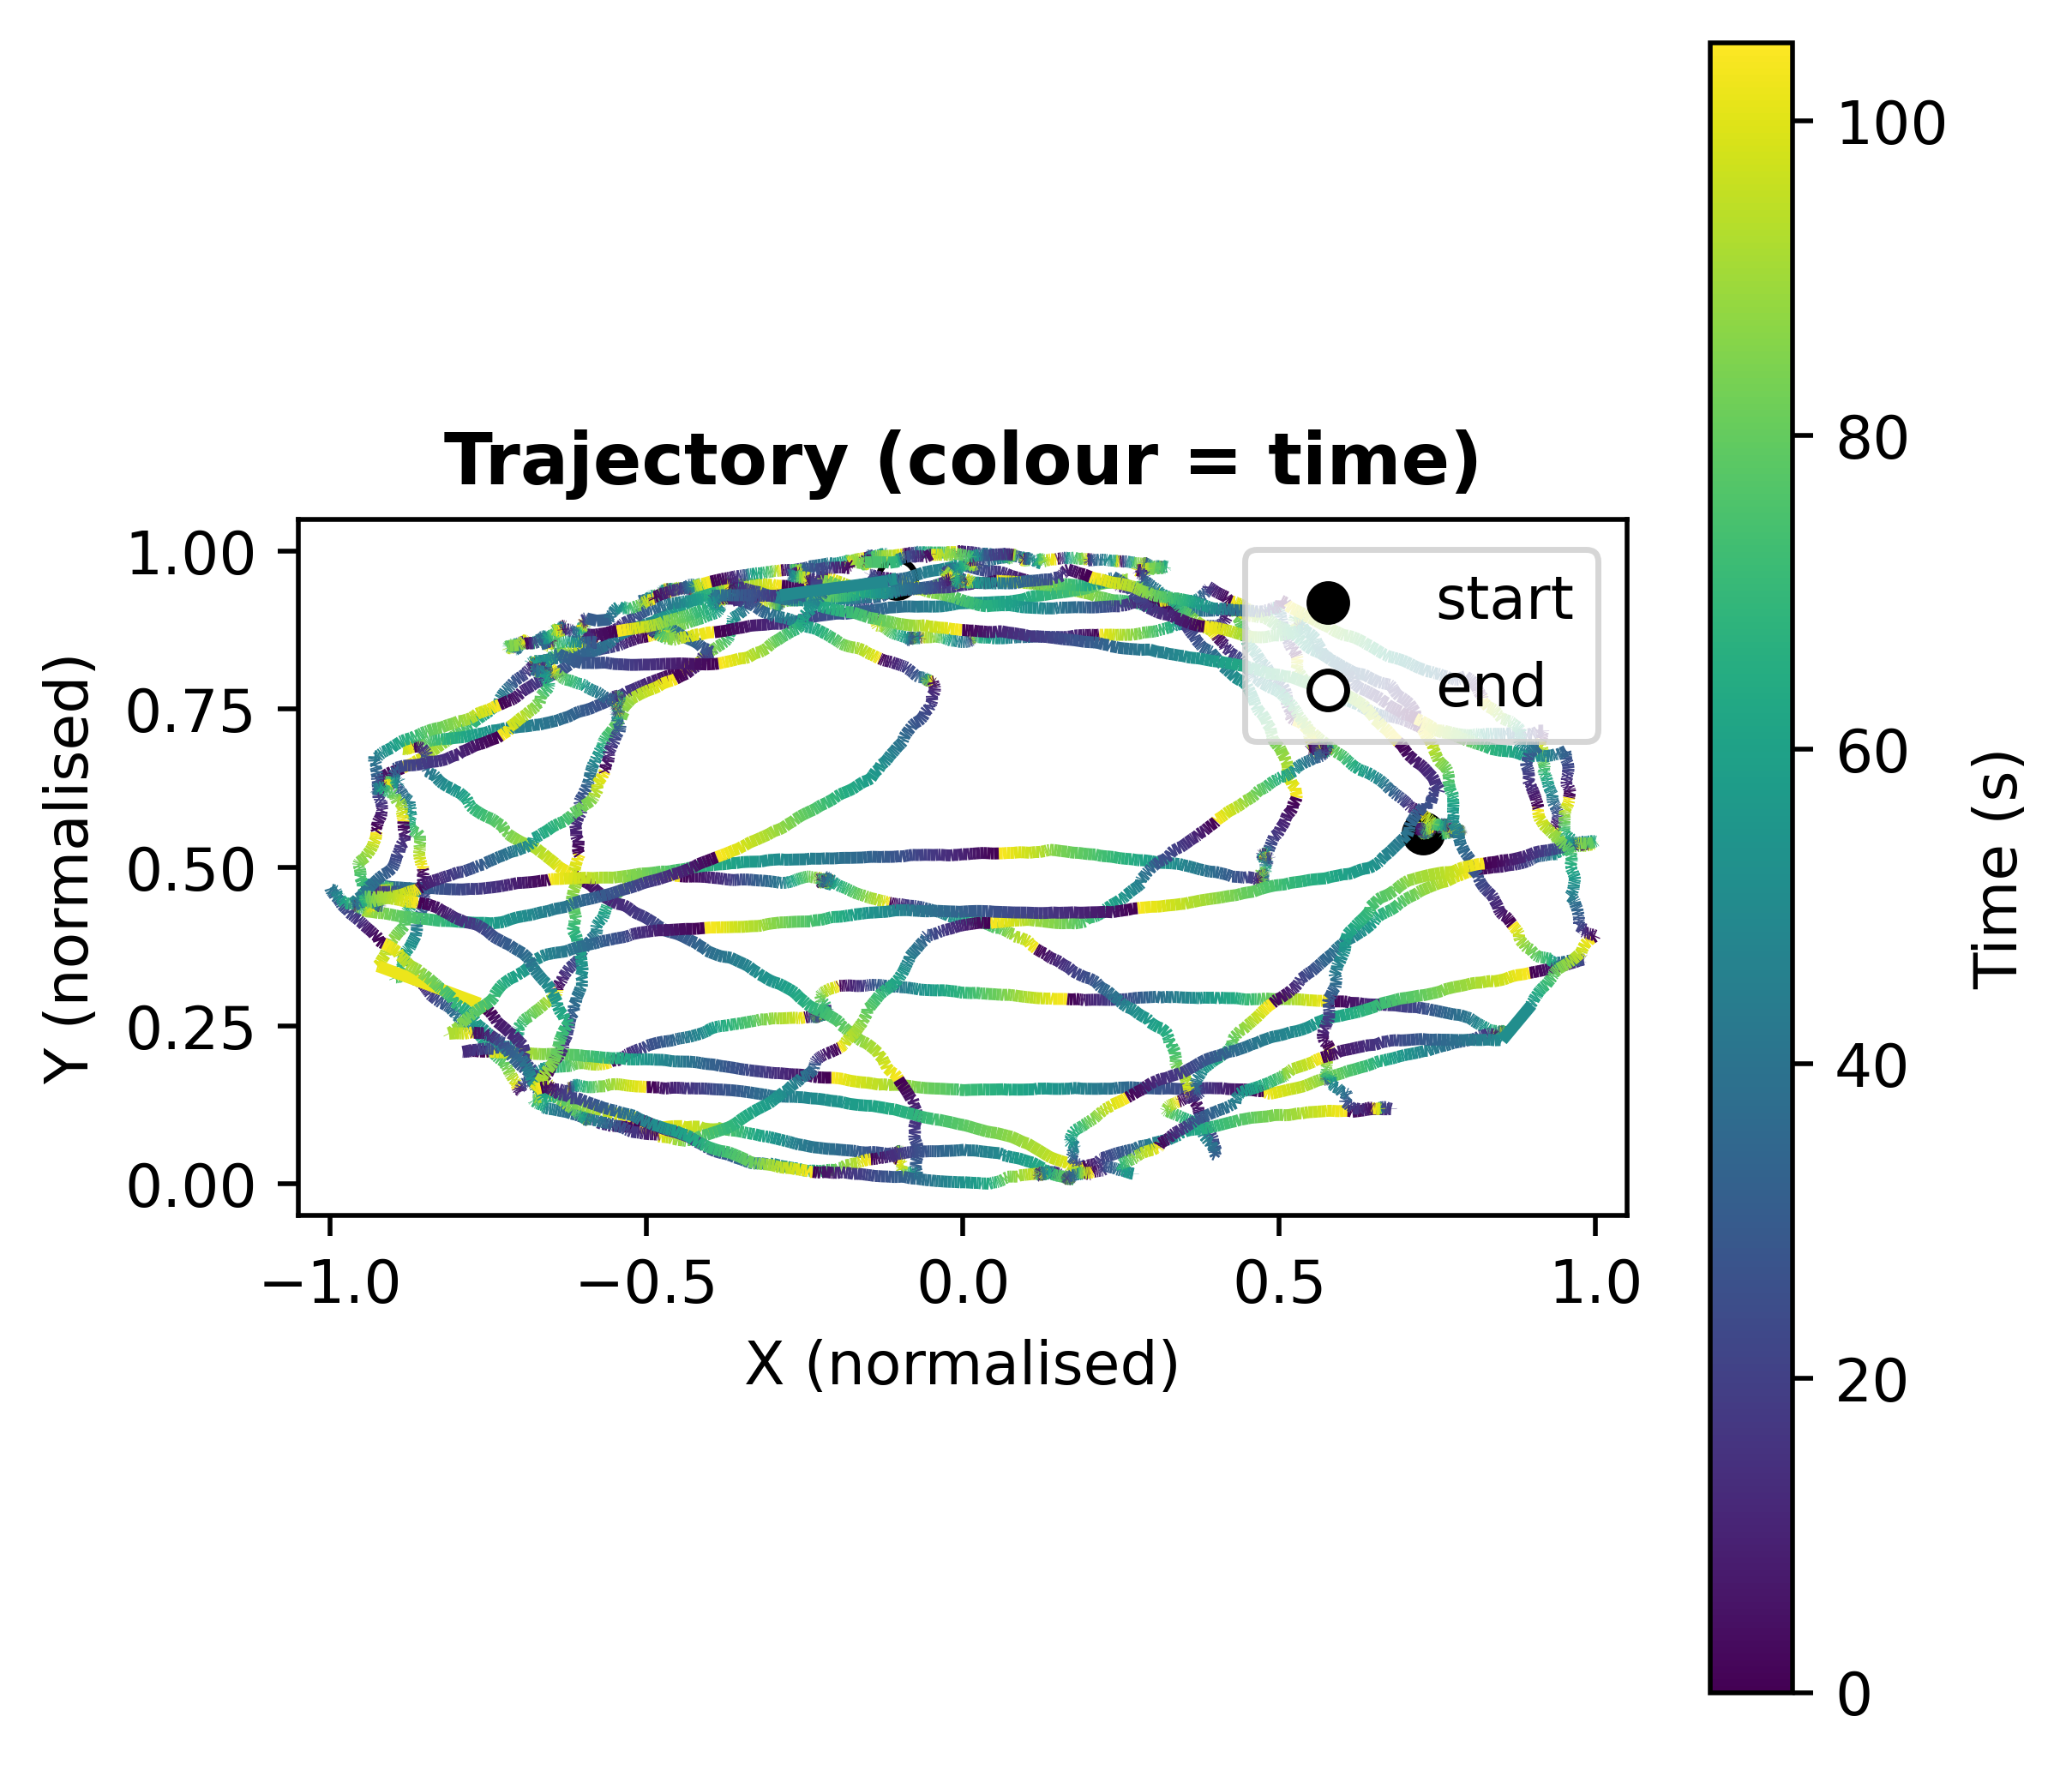

In [15]:
plot_trajectory_time_heatmap(fly1, scatter_tail=True)

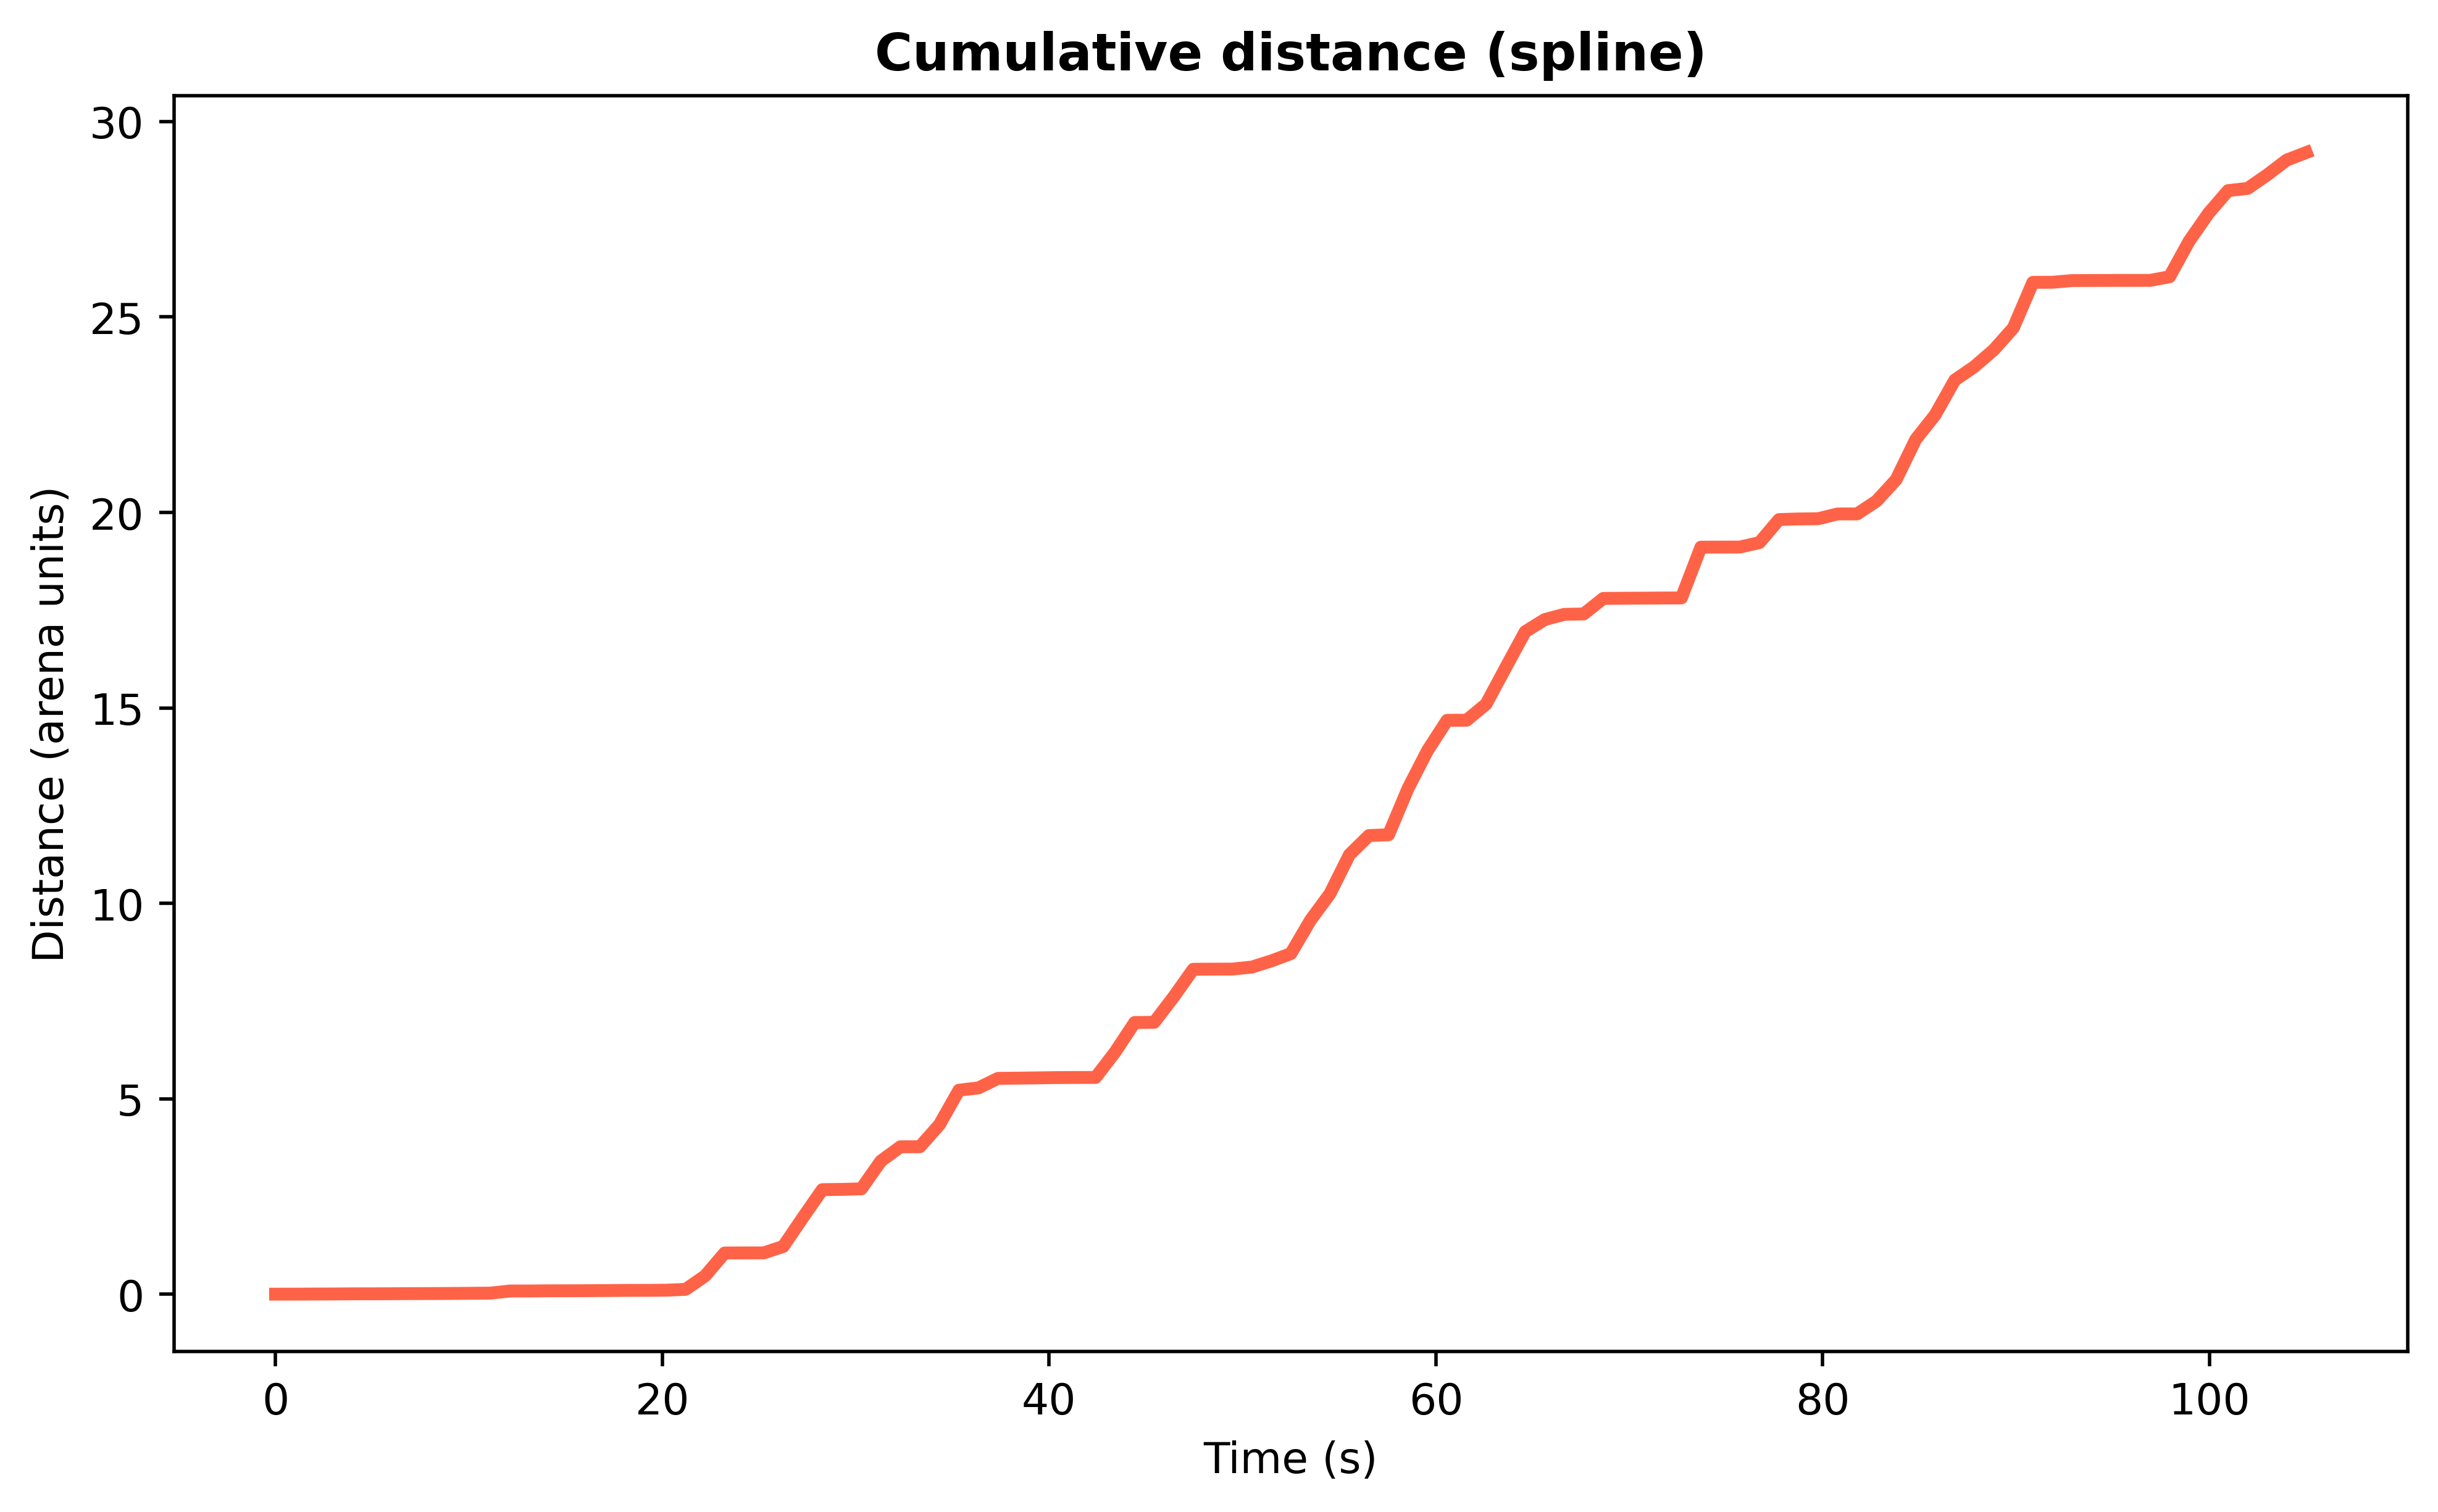

In [16]:
plot_cumulative_distance_spline(fly1)

## 3. Interpretación de resultados

### 🔍 **Algunas preguntas a responder:** <br/>

*   ¿Detectas patrones repetitivos de desplazamiento izquierda‑derecha (p. ej., “paseos” laterales)?
*   ¿Existe un sesgo claro hacia un lado del recinto?
*   ¿Hay áreas prácticamente inexploradas? ¿Por qué crees que ocurre esto?
*   ¿Crees que pueda deberse a estímulos ambientales o a preferencias individuales?
*  ¿La distribución espacial es homogénea o el animal muestra “lugares de reposo” frecuentes?
*  ¿En qué momentos se alcanzan los picos de velocidad y cuánto duran?
*  ¿La velocidad media cambia a lo largo de la sesión (p. ej., se fatiga o se activa conforme avanza el tiempo)?
*  ¿La trayectoria parece aleatoria o sigue rutas preferenciales?
*  ¿Se distinguen fases de exploración (trayecto amplio) frente a fases de localización (movimientos locales)?
* ¿La distancia recorrida aumenta de forma lineal, escalonada o con “mesetas” periódicas?

### 🔧    **Actividad:** Vuelve a correr el análisis con un archivo `.npz` diferente.

## 🚀 ¿Qué sigue?

Podemos explorar visualizaciones mas avanzadas, por ejemplo crear un **espectrograma** en el que podemos ver qué tan fuerte están presentes los distintos ritmos (frecuencias) de una señal a lo largo del tiempo. Basicamente nos da la siguiente información: <br/>
Eje X (horizontal): el tiempo que transcurre.<br/>
Eje Y (vertical): las frecuencias (qué tan rápido oscila la señal).<br/>
Colores: la intensidad o “potencia” de cada frecuencia en cada momento (claro = más fuerte, oscuro = más débil).<br/><br/>

A nivel biológico esto nos podría permitir, entre otras cosas:

*   Detectar patrones rítmicos: puedes descubrir si el animal alterna sistemáticamente entre exploración y reposo, o si tiene ráfagas de búsqueda de alimento.
*   Comparar estados o tratamientos: un tratamiento farmacológico puede aplanar el espectrograma (menos ritmos) o introducir nuevas bandas de frecuencia
*   Caracterizar la personalidad locomotora: algunos individuos muestran “motores en marcha” (espectro lleno en medias‑altas frecuencias), otros son pausados (energía confinada a bajas frecuencias).

### 🔍 ¿Se te ocurren otras gráficas/análisis? No dudes en intentar implementarlas!

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

def speed_spectrogram(animal_obj,
                      preset      = "A",          # "A", "B" or "C" (see below)
                      raw_speed   = None,         # optional 100 Hz series
                      cmap        = "magma"):
    """
    Plot a spectrogram of speed.

    Presets
    -------
    "A" : 1 Hz spline, 32 s window        – slow wander / pause rhythms
    "B" : 10 Hz (interp), 25.6 s window   – 0.1-10 s bursts and pauses
    "C" : 100 Hz (needs raw_speed), 5 s   – sub-second detail

    Parameters
    ----------
    animal_obj   : animal_behavior_stats
                 Must contain animal_obj.spline_sp (1 Hz, length 105).
    preset     : str  "A", "B", or "C"
    raw_speed  : ndarray | None
                 If you recorded 100 Hz speed, pass it here for preset "C".
                 Otherwise the function will up-sample the spline (OK but lower fidelity).
    cmap       : str  Matplotlib colormap name
    """

    # ------------------------------------------------------ preset table
    presets = {
        "A": dict(fs=1,   nperseg=32,  noverlap=16,
                  title="Spectrogram – 1 Hz (32 s window)"),
        "B": dict(fs=10,  nperseg=256, noverlap=128,
                  title="Spectrogram – 10 Hz (25 s window)"),
        "C": dict(fs=100, nperseg=512, noverlap=256,
                  title="Spectrogram – 100 Hz (5 s window)"),
    }
    if preset not in presets:
        raise ValueError("preset must be 'A', 'B' or 'C'")

    p = presets[preset]

    # ------------------------------------------------------ get speed series
    spline_speed = animal_obj.spline_sp.iloc[:, 0].values   # 1 Hz, length 105 s

    if p["fs"] == 1:
        speed = spline_speed                                   # 1 Hz ready
    elif p["fs"] == 10:
        # up-sample the spline to 10 Hz (linear interpolation)
        t_old = animal_obj.time                                  # 0…105 (step 1 s)
        t_new = np.arange(0, animal_obj.trial_length, 1/p["fs"]) # 0…105 (step 0.1 s)
        speed = np.interp(t_new, t_old, spline_speed)
    elif p["fs"] == 100:
        if raw_speed is not None and len(raw_speed) == 10500:
            speed = raw_speed                                  # use true 100 Hz
        else:
            # fall back to up-sampling spline (lower fidelity)
            t_old = animal_obj.time
            t_new = np.arange(0, animal_obj.trial_length, 1/p["fs"])
            speed = np.interp(t_new, t_old, spline_speed)
            print(" Using up-sampled spline for 100 Hz; "
                  "pass raw_speed=… for best resolution.")

    # ------------------------------------------------------ spectrogram
    f, t, Sxx = spectrogram(speed,
                            fs       = p["fs"],
                            nperseg  = p["nperseg"],
                            noverlap = p["noverlap"],
                            detrend  = False,
                            scaling  = "density")

    Sxx_dB = 10 * np.log10(Sxx + 1e-12)

    # ------------------------------------------------------ plot
    plt.figure(figsize=(10, 4))
    mesh = plt.pcolormesh(t, f, Sxx_dB, shading="auto", cmap=cmap)
    plt.colorbar(mesh, label="Power (dB)")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.ylim(0, p["fs"]/2)              # Nyquist
    plt.title(p["title"], fontweight="bold")


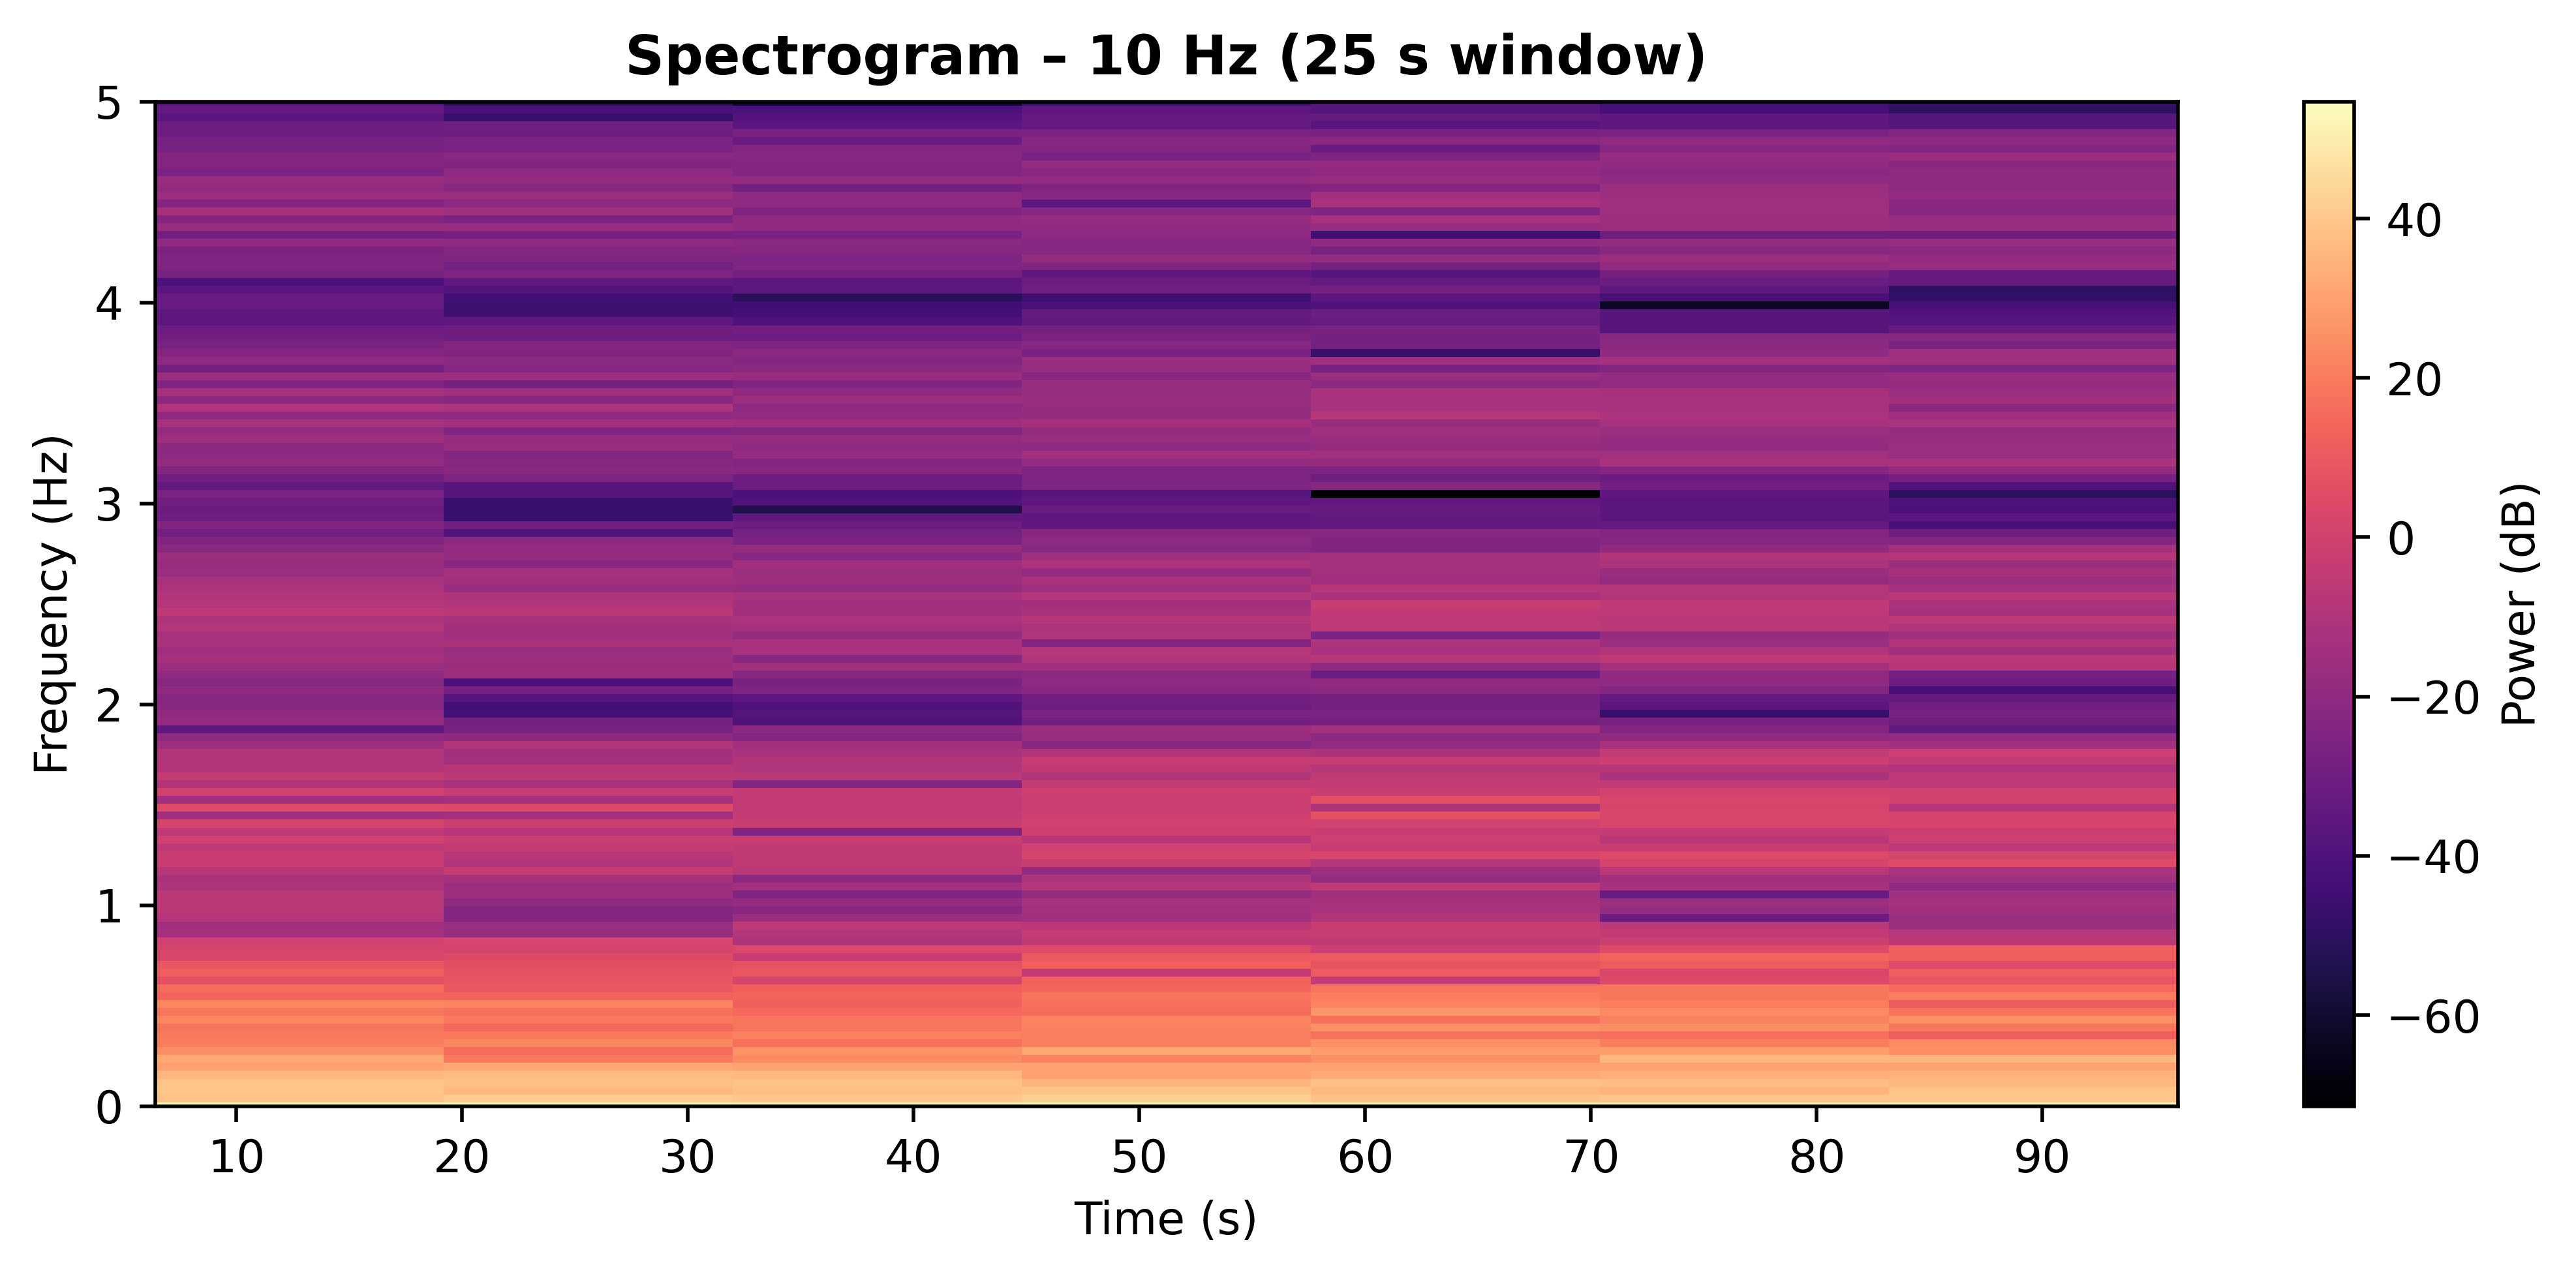

In [18]:
speed_spectrogram(fly1, preset="B")